# Programació per a la bioinformàtica


Unitat 4: ADN, ARN, seqüències i motius (Part 1)
---------------------------------------------------------

## Etiquetes

Benvinguts a la PAC de l'unitat 4. Sota aquestes línies trobareu exercicis i preguntes. Cadascun d'ells tindrà una etiqueta que indica els recursos necessaris per a resoldre'ls. Hi ha tres possibles etiquetes:




* **<font color="green" size="+2">MU</font>** **Materials unitat**: les eines necessàries per a realitzar l'activitat es poden trobar en els materials de l'assignatura.

* **<font color="blue" size="+2">EG</font>** **Consulta externa guiada**: l'activitat pot requerir utilitzar eines que no es troben en els materials de l'assignatura, però l'enunciat conté indicacions de com trobar la informació addicional necessària.

* **<font color="gold" size="+2">CI</font>** **Consulta externa independent**: l'activitat pot requerir utilitzar eines que no es troben en els materials de l'assignatura, i l'enunciat no inclou les indicacions de com trobar la informació addicional. L'estudiant haurà de buscar aquesta informació independentment.)

## Tests

Abans de res, dir que en l'àmbit de la programació és molt comú utilitzar tests (anomenats tests unitaris) durant la codificació dels programes. Els tests serveixen per a saber si un programa es comporta com s'espera. És a dir, serveixen per a validar la funcionalitat del programa, no per a determinar la qualitat del codi.

Així doncs, els tests són un gran aliat del programador. És per això que la majoria dels exercicis i fins i tot alguna de les preguntes tindran una cel·la sota elles amb un comentari en la primera línia amb el títol: `# Test Exercici X` o `Test Pregunta X`

**IMPORTANT**: **no heu de modificar les cel·les de test**.

Si les executeu, CoLab executará el test corresponent sobre el vostre codi. Depenent del resultat, sabreu que:

* Si el test falla, llavors el vostre codi no funciona com s'espera. Així doncs, haureu de corregir-ho.

* Si el test no falla, llavors el vostre codi es comporta com s'espera. Tanmateix, això no significa que l'el exercici sigui correcte, ja que hi ha situacions en les quals es demana usar una determinada funció o estructura. Per exemple, imagineu que es demana resoldre un exercici usant un ``for`` i, en el seu lloc, useu un ``while``. Segurament el vostre programa passaria el test (perquè funciona com s'espera), però no respecta un requisit de l'enunciat.

**Per a poder executar els tests primer heu d'executar la següent cel·la de codi**: (Tan sols una vegada per sessió)

In [141]:
#!pip install ipytest
import ipytest
ipytest.autoconfig()

### Instruccions d'ús
A continuació, presentarem algunes observacions i exemples d'ús de la llibreria BioPython en l'àmbit del tractament de seqüències d'ADN, ARN i proteïnes. Recordeu que podeu anar executant els exemples per a obtenir els seus resultats.

### Primers passos
Com sempre, importarem la llibreria i comprovarem que tot funciona:

In [142]:
#!pip install biopython
import Bio  #És important executar aquesta cel·la cada vegada que tanquem i obrim el notebook si volem executar recursos de biopython

## Format FASTA
La informació genòmica, que abasta des de nucleòtids fins a seqüències de residus peptídics, és a dir, els aminoàcids fonamentals que componen les proteïnes, sol presentar-se en format d'arxiu FASTA. Aquest format és àmpliament reconegut en la comunitat bioinformàtica i gairebé s'ha establert com un estàndard degut a la seva popularitat en el maneig de seqüències biològiques.

**La primera línia**, identificada pel símbol '>', correspon a la capçalera (header) en un arxiu en format FASTA. En aquest capçalera, comunament s'inclou informació com un identificador, el nom de l'organisme, el cromosoma, entre altres dades rellevants (__important!__ que aquesta informació estigui separada per espais ' '). És important destacar que la presència d'aquesta línia no és obligatòria.

A continuació de la capçalera, es presenta **la seqüència**, la qual s'estén fins al pròxim símbol '>', marcant el començament d'un nou capçalera, o fins al final de l'arxiu. En general, les línies que componen la seqüència solen tenir una longitud inferior a 80 caràcters.

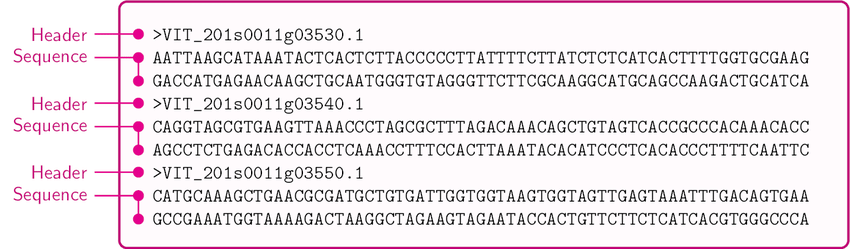


Font: [DOI:10.3390/info7040056](https://www.researchgate.net/figure/A-sample-of-the-Multi-FASTA-file_fig1_309134977)

**Un arxiu multifasta** és simplement un arxiu de text pla que segueix el format comunament utilitzat en bioinformàtica. Aquest format és estructurat de la següent manera:

>`>Identificador_secuencia_1 Receptor1 Chr1`<br>
>`MTEITAAMVKELRESTGAGMMDCKNALSETNGDFDKAVQLLREKGLGKAAKKADRLAAEG`
>`LVSVKVSDDFTIAAMRPSYLSYEDLDMTFVENEYKALVAELEKENEERRRLKDPNKPEHK`<br>
>`>Identificador_secuencia_2 Receptor2 Chr12`<br>
>`SATVSEINSETDFVAKNDQFIALTKDTTAHIQSNSLQSVEELHSSTINGVKFEEYLKSQI`
>`ATIGENLVVRRFATLKAGANGVVNGYIHTNGRVGVVIAAACDSAEVASKSRDLLRQICMH`

En el context de seqüències de proteïnes, els caràcters en majúscula representen els diferents residus, sent 'M' corresponent a metionina, 'T' a treonina, i així successivament. Aquests residus formen la cadena d'aminoàcids que constitueix la proteïna codificada per la seqüència. En la següent taula podem veure la nomenclatura per a tots els aminoàcids:

## 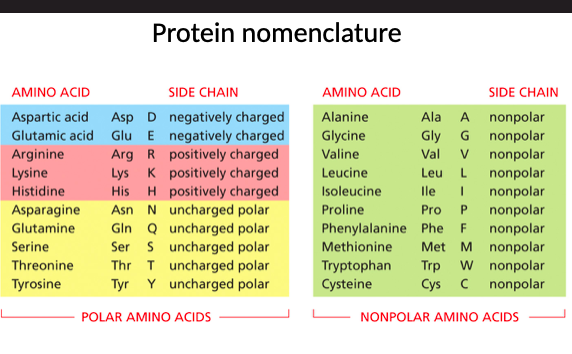
Font: [chegg.com](https://www.chegg.com/homework-help/questions-and-answers/protein-nomenclature-amino-acid-side-chain-aspartic-acid-asp-d-negatively-charged-glutamic-q84931246)



En seqüència genòmica, trobarem exclusivament alguna de les quatre possibles bases: G, A, T o C, en el cas de l'ADN, o les mateixes bases amb l'excepció d'U en lloc de T, si es tracta d'ARN. És important assenyalar que en aquestes seqüències també poden aparèixer símbols addicionals, com a salts de seqüència indicats pel símbol '-', o altres casos particulars.

Per a obtenir una llista més detallada d'aquests símbols i els seus significats, es pot consultar la següent referència: [Llista de Símbols en Format FASTA](https://zhanggroup.org/FASTA/#:~:text=FASTA%20format%20is%20a%20text,represented%20using%20single%2Dletter%20codes.). Aquesta font proporciona una visió exhaustiva dels símbols que poden aparèixer en el format FASTA i les seves interpretacions específiques.

A continuació en els següents links, trobareu informació que us pot ajudar a entendre aquests conceptes:



-  [Format fasta en ncbi](https://www.ncbi.nlm.nih.gov/genbank/fastaformat/)

-  [Glossari de ensembl](https://www.ensembl.org/info/website/glossary.html)

## Fitxer multifasta exemple:

En el directori `data` tenim un fitxer multiFASTA d'exemple, `*multipleSeqs.fa`. Ho llegirem amb la llibreria [BioPython](https://biopython.org/docs/1.75/api/index.html):


In [143]:
from Bio import SeqIO

# Obtenim totes les seqüències que trobi en el fitxer, indicant
# el tipus de format 'fasta':
#!wget -nc https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad4/multipleSeqs.fa --no-check-certificate # Descarreguem el fitxer al nostre drive


In [144]:
records = SeqIO.parse("multipleSeqs.fa.txt", "fasta") #tenim el fitxer en format .txt perque l'hem hagut de descarregar manualment ja que estic
# treballant en local en windows i !wget no funciona
for seq_record in records:
    # Per a cada seqüència, imprimirem la seva ID i la seva longitud
    print('ID: "', seq_record.id, '" - longitud: ', len(seq_record))

ID: " NT_033779.5 " - longitud:  134
ID: " NC_004353.4 " - longitud:  125
ID: " AM711902.1 " - longitud:  140
ID: " NC_024512.1 " - longitud:  81
ID: " NC_019843.3 " - longitud:  300
ID: " NC_001802.1 " - longitud:  557


Cadascun dels `seq_record` que llegim és un objecte `SeqRecord` que conté un objecte de tipus `Seq` (una seqüència en BioPython) al costat d'altres metadades, com la seva ID, per exemple. Anem ara a comptar el nombre de nucleòtids de cada tipus. A més definirem un argument, "organisme", per a seleccionar l'organisme que volem seleccionar.:

In [145]:
from Bio import SeqIO

def comptar_nucleotids_biopython(fasta="multipleSeqs.fa.txt", organisme = ''):
  '''fasta: arxiu format fasta
     organisme: Organisme a seleccionar en el multifasta.
     Si no s'especifica, retorna tots'''
  records = SeqIO.parse(fasta, "fasta")
  nucleotidos = {}
  for seq_record in records:
      # Si no especifiquem cap organisme, ens retorna tota la informació de tots els organismes
      if organisme.lower() in seq_record.description.lower():
        nucleotidos[seq_record.id] = {"A": seq_record.seq.count("A"),
                        "C": seq_record.seq.count("C"),
                        "G": seq_record.seq.count("G"),
                        "T": seq_record.seq.count("T")}
  return nucleotidos

for i, nucl in comptar_nucleotids_biopython("multipleSeqs.fa.txt").items():
      print(f"Secuencia {i}:")
      print(f"Número de A: {nucl['A']}")
      print(f"Número de C: {nucl['C']}")
      print(f"Número de G: {nucl['G']}")
      print(f"Número de T: {nucl['T']}")
      print()

Secuencia NT_033779.5:
Número de A: 39
Número de C: 26
Número de G: 29
Número de T: 40

Secuencia NC_004353.4:
Número de A: 46
Número de C: 0
Número de G: 0
Número de T: 79

Secuencia AM711902.1:
Número de A: 45
Número de C: 33
Número de G: 26
Número de T: 36

Secuencia NC_024512.1:
Número de A: 32
Número de C: 17
Número de G: 10
Número de T: 22

Secuencia NC_019843.3:
Número de A: 63
Número de C: 62
Número de G: 70
Número de T: 105

Secuencia NC_001802.1:
Número de A: 165
Número de C: 114
Número de G: 166
Número de T: 112



Ara extraurem els resultats filtrant per "Drosophila":

In [146]:
for i, nucl in comptar_nucleotids_biopython("multipleSeqs.fa.txt", organisme = "Drosophila").items():
      print(f"Secuencia {i}:")
      print(f"Número de A: {nucl['A']}")
      print(f"Número de C: {nucl['C']}")
      print(f"Número de G: {nucl['G']}")
      print(f"Número de T: {nucl['T']}")
      print()

Secuencia NT_033779.5:
Número de A: 39
Número de C: 26
Número de G: 29
Número de T: 40

Secuencia NC_004353.4:
Número de A: 46
Número de C: 0
Número de G: 0
Número de T: 79

Secuencia NC_024512.1:
Número de A: 32
Número de C: 17
Número de G: 10
Número de T: 22




### Exercici 1 **<font color="green" size="+2">MU</font>**
Escriviu el codi per a comptar el nombre de bases com l'exemple anterior, però __SENSE utilitzar la llibreria *BioPython__. Com a arguments de la funció ha d'haver-hi els dos següents:
- __fasta__: l'arxiu *fasta input
- __organisme__: dins de cada capçalera de les seqüències de l'arxiu fasta, es troba el nom de l'organisme. En aquest arxiu tenim seqüències de Drosophila, alguns virus i Canis. Si no es proporciona nom de cap, la funció ha de retornar la informació de totes les seqüències del multiFASTA.

In [147]:
import os

def comptar_nucleotids(fasta="multipleSeqs.fa.txt", organisme=''):
    # Completa la teva resposta
    with open(fasta,'r') as f:
        file = f.read().split('>')[1:]
        records = [x.split('\n')[:-1] for x in file]
        #print(records)
    nucleotidos = {}
    for seq_record in records:
        if organisme.lower() in seq_record[0].lower():
            id = seq_record[0].split(' ')[0]
            sequence = ''.join(seq_record[1:])
            nucleotidos[id] = {"A": sequence.count("A"),
                            "C": sequence.count("C"),
                            "G": sequence.count("G"),
                            "T": sequence.count("T")}
    return nucleotidos
# Imprimim tots els resultats per pantalla
for i, nucl in comptar_nucleotids(organisme = '').items():
    print(f"Secuencia {i}:")
    print(f"Número de A: {nucl['A']}")
    print(f"Número de C: {nucl['C']}")
    print(f"Número de G: {nucl['G']}")
    print(f"Número de T: {nucl['T']}")
    print()

Secuencia NT_033779.5:
Número de A: 39
Número de C: 26
Número de G: 29
Número de T: 40

Secuencia NC_004353.4:
Número de A: 46
Número de C: 0
Número de G: 0
Número de T: 79

Secuencia AM711902.1:
Número de A: 45
Número de C: 33
Número de G: 26
Número de T: 36

Secuencia NC_024512.1:
Número de A: 32
Número de C: 17
Número de G: 10
Número de T: 22

Secuencia NC_019843.3:
Número de A: 63
Número de C: 62
Número de G: 70
Número de T: 105

Secuencia NC_001802.1:
Número de A: 165
Número de C: 114
Número de G: 166
Número de T: 112



#### Notes importants

- No podeu agafar el contingut del fitxer i copiar en la cel·la com si fos un string.
- Cada nova seqüència ve identificada pel caràcter '>'. Utilitzeu tot el que ve després d'aquest caràcter i fins que acabi la línia per a utilitzar-lo com la clau d'un diccionari. El valor per a aquesta clau serà la resta de la seqüència que heu de tractar.
- En el header (línia que conté >) ve el nom de l'organisme a filtrar. Si a l'argument "organisme" no se li dona cap valor, ha de retornar el resultat per a totes les seqüències.

Testeja que el resultat de la teva funció `comptar_nucleotids` és idèntic al que retorna la funció `comptar_nucleotids_biopython` que t'hem donat codificada.

In [148]:
%%ipytest
# Test Exercici 1
def test_nucleotidos():
  assert comptar_nucleotids_biopython("multipleSeqs.fa.txt") == comptar_nucleotids("multipleSeqs.fa.txt")
  assert comptar_nucleotids_biopython("multipleSeqs.fa.txt", organisme = 'Drosophila') == comptar_nucleotids("multipleSeqs.fa.txt", organisme = 'Drosophila')
  assert comptar_nucleotids_biopython("multipleSeqs.fa.txt", organisme = 'Canis') == comptar_nucleotids("multipleSeqs.fa.txt", organisme = 'Canis')
  assert comptar_nucleotids_biopython("multipleSeqs.fa.txt", organisme = 'Coronavirus') == comptar_nucleotids("multipleSeqs.fa.txt", organisme = 'Coronavirus')

.                                                                                            [100%]
1 passed in 0.06s


## Què és un DataFrame?
Un DataFrame és una estructura de dades bidimensional tabular i etiquetada en la qual pots emmagatzemar i manipular dades de manera eficient. Cada columna en un DataFrame pot ser d'un tipus diferent (sencer, cadena, flotant, etc.), i és similar a un full de càlcul o una taula SQL. Els DataFrames són especialment útils quan treballes amb grans conjunts de dades i necessites realitzar operacions complexes de manera eficient.

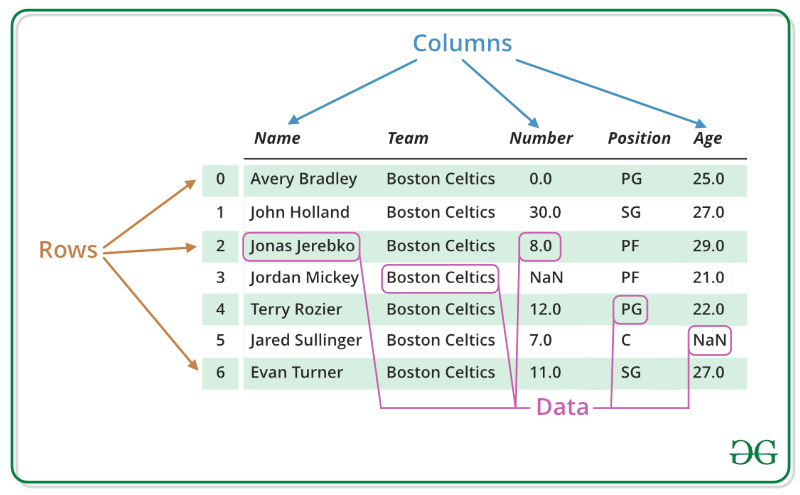

**Nota:** En la següent referència, trobareu exemples per a practicar i les funcions més rellevants:

https://www.geeksforgeeks.org/python-pandas-dataframe/ (font de l'imatge)


### Pandas: Llibreria Fonamental per a manipulació de DataFrames
**Pandas** és una llibreria de Python que proporciona estructures de dades d'alt rendiment i eines d'anàlisis de dades. Va ser creada per a facilitar el maneig i anàlisi de dades en Python, oferint dues estructures principals: Sèries i DataFrames.

Característiques Clau de Pandas:

- __DataFrame:__

> Pandas proporciona les estructures de dades DataFrame i Sèries. Un DataFrame és una col·lecció de Sèries, i cada Sèrie és essencialment una columna en el DataFrame.

- __Indexació i Etiquetatge:__

> Els DataFrames i Sèries en Pandas estan etiquetats, la qual cosa facilita la indexació i recuperació de dades.

- __Operaciones Eficientes:__

> Pandas permet realitzar operacions eficients en grans conjunts de dades sense requerir bucles explícits.

- __Entrada/Sortida de Dades:__

> Aquesta llibreria pot suportar la lectura i escriptura de dades en diversos formats, com CSV, Excel, SQL, i més.

**Nota:** Podeu expandir més informació sobre aquesta llibreria en la web oficial amb tota la documentació de la llibreria Pandas:

-  https://pandas.pydata.org/pandas-docs/stable/

A continuación, os dejamos algunos ejemplos para trabajar con esta librería:

1.   **Creació de Dataframe**
2.   **Concatenació de Dataframes**
3.   **Ordenar Dataframe per una columna**
4.   **Extreure columna pel seu nom**
5.   **Extreure fila per índex**
6.   **Exportar Dataframes**
7.   **Importar csv/tsv/... a Dataframe**


1.  __Creació de Dataframe__

In [149]:
import pandas as pd

# Creació de DataFrame a partir de diccionari
from_dict = {'Extensión': ['.Fasta', '.Fastq', '.Fa'],
             'Cromosoma': [2, 3, 4],
             'Longitud': [150, 160, 180]}
# Convertim el diccionari en Dataframe
df_1 = pd.DataFrame(from_dict)

# Mostra el DataFrame inicial
print("DataFrame Inicial:")
df_1

DataFrame Inicial:


,Extensión,Cromosoma,Longitud
0,.Fasta,2,150
1,.Fastq,3,160
2,.Fa,4,180


2. __Concatenació de Dataframes__

In [150]:
# Afegir Nova Dada al DataFrame
dict_2 = {'Extensión': '.fasta.gz',
          'Cromosoma': 15,
          'Longitud': 200}
# Convertim el diccionari en Dataframe
df_2 = pd.DataFrame([dict_2])
# Combina els DataFrames utilitzant concat.

df_combi = pd.concat([df_1, df_2], ignore_index=True)

# Mostra el DataFrame combinat
print("\nDataFrame Combinat:")
df_combi


DataFrame Combinat:


,Extensión,Cromosoma,Longitud
0,.Fasta,2,150
1,.Fastq,3,160
2,.Fa,4,180
3,.fasta.gz,15,200


Nota:`ignore_index=True` és una bona pràctica quan estàs combinant DataFrames i desitges que el DataFrame resultant tingui índexs seqüencials des de zero.

3.  __Ordenar Dataframe per una columna__

In [151]:
# Ordenar el DataFrame per columna 'Longitud' en ordre descendent
df_combi = df_combi.sort_values(by="Longitud", ascending=False)

# Mostra el DataFrame ordenat
print("\nDataFrame Ordenat per Longitud:")
df_combi


DataFrame Ordenat per Longitud:


,Extensión,Cromosoma,Longitud
3,.fasta.gz,15,200
2,.Fa,4,180
1,.Fastq,3,160
0,.Fasta,2,150


4.  __Extraer columna por su nombre__

In [152]:
# Extreure una Columna pel seu nom
columna_extension = df_combi['Extensión']
print("\nColumna 'Extensión':")
print(columna_extension)
# Es pot convertur a una llista
print("\nColumna 'Extensión' com una llista:")
print(columna_extension.tolist())


Columna 'Extensión':
3    .fasta.gz
2          .Fa
1       .Fastq
0       .Fasta
Name: Extensión, dtype: object

Columna 'Extensión' com una llista:
['.fasta.gz', '.Fa', '.Fastq', '.Fasta']


5.  __Extreure fila per índex__

**Nota:** en ordenar prèviament el dataframe, els índexs han canviat (3>2>1>0). Si diem l'índex 1, obtindrem la fila en la tercera posició.

In [153]:
# Extreure una Fila per Índex
fila_1 = df_combi.loc[1]
print("\nFila con Índice 1:")
print(fila_1)
# Es pot convertur a una llista
print("\nFila '1' como una lista:")
print(fila_1.tolist())


Fila con Índice 1:
Extensión    .Fastq
Cromosoma         3
Longitud        160
Name: 1, dtype: object

Fila '1' como una lista:
['.Fastq', 3, 160]


6.  __Exportar Dataframes__

**Nota:**`sep` podem especificar el separador. En aquest cas volem exportar la taula amb tabuladors com a separador('\t')

In [154]:
# Exportar DataFrame a un arxiu CSV
df_combi.to_csv('df_ejemplo.csv', index=False, sep='\t')

7.  __Importar csv/tsv/... a Dataframe__

In [155]:
# Importar DataFrame des d'un arxiu CSV
df_importat = pd.read_csv('df_ejemplo.csv', sep='\t')

# Mostra el DataFrame importat
print("\nDataFrame Importado desde CSV:")
df_importat


DataFrame Importado desde CSV:


,Extensión,Cromosoma,Longitud
0,.fasta.gz,15,200
1,.Fa,4,180
2,.Fastq,3,160
3,.Fasta,2,150


### Contingut GC
En genètica, el contingut de guanina i citosina (GC) s'entén com el percentatge entre els parells Guanina-Citosina en la molècula d'ADN o genoma i la resta de bases. Aquest percentatge es calcula de la forma següent:

$(G + C) * 100 / (A + C + G + T)$

Amb BioPython, calcular el contingut GC és molt senzill:

In [156]:
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

# Creem un objecte seqüencia que contingui els nucleòtids vàlids per a l'ADN
# definits per la IUPAC (Unió Internacional de Química Pura i Aplicada)
seq = Seq("AAGGTGTTCGGTCCTTCCGAGGAAGCTAAGGCCGCGTTGGGGTGAGACCCTCACTTCATCCGGTGAGTAG")

# Calculem el contingut mitjançant la funció GC():
contingut_gc=gc_fraction(seq)

#Per obtenir el percentatge mutipliquem per 100
contingut_gc=gc_fraction(seq)*100
print(contingut_gc)

58.57142857142858


### Exercici d'entrenament 1
Per a la mateixa seqüència, escriviu el codi per a calcular el contingut GC sense utilitzar la llibreria BioPython:

In [157]:
seq = "AAGGTGTTCGGTCCTTCCGAGGAAGCTAAGGCCGCGTTGGGGTGAGACCCTCACTTCATCCGGTGAGTAG"
# Resposta
G = seq.count('G')
C = seq.count('C')
long = len(seq)
contingut_GC = ((G+C)/long)*100
contingut_GC

58.57142857142858


### Exercici 2 **<font color="blue" size="+2">EG</font>**
Escriviu el codi per una funció on es generi una Dataframe, taula resumeixen a partir de l'arxiu `multipleSeqs.fa` que contingui les següents columnes:



* **ID_seq**: Conté l'ID de la seqüència fasta (e.g. NC_001802.1)
* **G+C_perc**: Conté el percentatge de G+C de cadascuna de les seqüències de l'arxiu multifasta. Arrodonir a 2 decimals. No es pot fer servir BioPython per calcular el contingut de GC.
* **Purines_perc**: Conté el percentatge de purinas de cadascuna de les seqüències de l'arxiu multifasta. Arrodonir a 2 decimals.
* **Pirimidines_perc**: Conté el percentatge de pirimidines de cadascuna de les seqüències de l'arxiu multifasta. Arrodonir a 2 decimals.
* **Longitud**: Longitud total de la seqüència

Aquesta funció ha de rebre com a argument un arxiu fasta (utilitzarem l'arxiu multifasta anterior) i té un altre argument (`output_file`) per a decidir si guardar o no aquesta taula en un arxiu. Per defecte, __NO__ s'ha de desar l'arxiu. El DataFrame ha d'estar ordenat per la columna `Longitud`.

Per tant hem de crear una variable Dataframe ``"fasta_resum"`` i generar una taula en format tsv (tab separated value) amb el nom: ``"fasta_resum.tsv"``

In [158]:

# Obtenim el fitxer "multipleSeqs.fa"
#!wget -nc https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad4/multipleSeqs.fa --no-check-certificate # Descargamos el fichero a nuestro drive


In [159]:
import pandas as pd
from Bio import SeqIO

def calculate_percentages(sequence):
    length = len(sequence)
    if length == 0:
        return 0.0, 0.0, 0.0

    count_g = sequence.seq.count('G')
    count_c = sequence.seq.count('C')
    count_a = sequence.seq.count('A')
    count_t = sequence.seq.count('T')

    gc_content = ((count_g + count_c) / length) * 100
    purine_content = ((count_a + count_g) / length) * 100
    pyrimidine_content = ((count_t + count_c) / length) * 100

    return round(gc_content, 2), round(purine_content, 2), round(pyrimidine_content, 2)

def resum_fasta(fasta, output_file=None):
    sequences = SeqIO.parse(fasta, "fasta")


    data = []

    for sequence in sequences:
        gc_perc, purines_perc, pyrimidines_perc = calculate_percentages(sequence)
        length = len(sequence)

        data.append({
            "Id_seq": sequence.id,
            "G+C_perc": gc_perc,
            "Purines_perc": purines_perc,
            "Pirimidines_perc": pyrimidines_perc,
            "Longitud": length
        })

    fasta_resum = pd.DataFrame(data)
    fasta_resum = fasta_resum.sort_values(by="Longitud", ascending=False)

    if output_file:
        fasta_resum.to_csv(output_file, sep='\t', index=False)

    return fasta_resum

# Exemple d'us:
arxiu_multifasta = "multipleSeqs.fa.txt"
fasta_resum = resum_fasta(arxiu_multifasta, output_file=False)
fasta_resum

,Id_seq,G+C_perc,Purines_perc,Pirimidines_perc,Longitud
5,NC_001802.1,50.27,59.43,40.57,557
4,NC_019843.3,44.00,44.33,55.67,300
2,AM711902.1,42.14,50.71,49.29,140
0,NT_033779.5,41.04,50.75,49.25,134
1,NC_004353.4,0.00,36.80,63.20,125
3,NC_024512.1,33.33,51.85,48.15,81


Testeja que el teu codi és correcte amb el següent test unitari


In [160]:
%%ipytest
import pytest
# Test Exercici 2
def test_gc():
  assert fasta_resum['Id_seq'].tolist() == ['NC_001802.1','NC_019843.3','AM711902.1', 'NT_033779.5', 'NC_004353.4', 'NC_024512.1']
  assert fasta_resum['G+C_perc'].tolist() == [50.27, 44.0, 42.14, 41.04, 0.0, 33.33]
  assert fasta_resum['Purines_perc'].tolist() == [59.43, 44.33, 50.71, 50.75, 36.8, 51.85]
  assert fasta_resum['Pirimidines_perc'].tolist() == [40.57, 55.67, 49.29, 49.25, 63.2, 48.15]


.                                                                                            [100%]
1 passed in 0.04s


### Exercici 3  **<font color="gold" size="+2">CI</font>**
Escriviu una funció per a representa gràficament amb un **piechart** la freqüència de cadascuna de les bases (A/C/G/T) per cadascuna de les seqüències de l'arxiu `multipleSeqs.fa`. Cada piechart ha de tenir com titúlo l'ID de la seqüència corresponent (e.g. **Composició de Bases en Seqüència NC_001802.1**). A continuació us deixem un exemple de com hauria de ser un d'aquests plots:


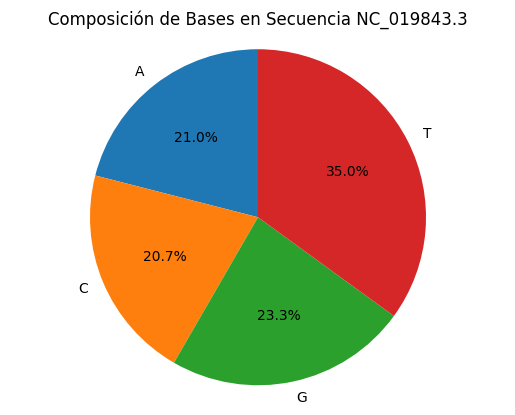

Pista: S'aplica l'après en la unitat 3 (**llibreria matplotlib**). Consulteu la funció que generi un piechart dins de `matplotlib.pyplot`

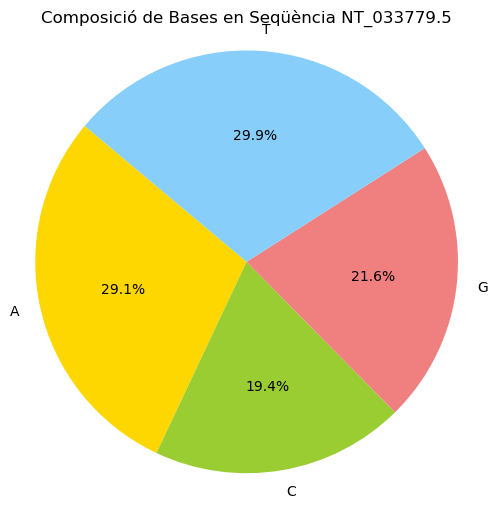

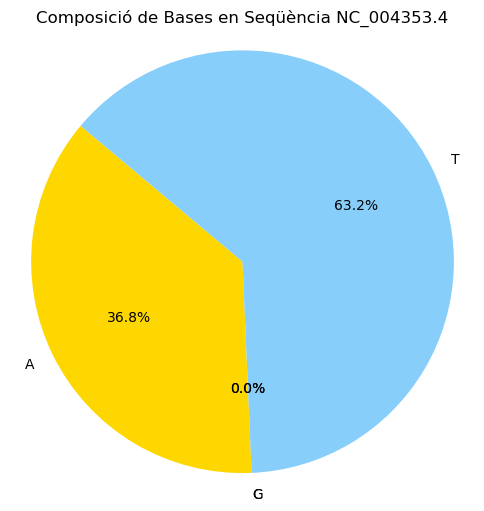

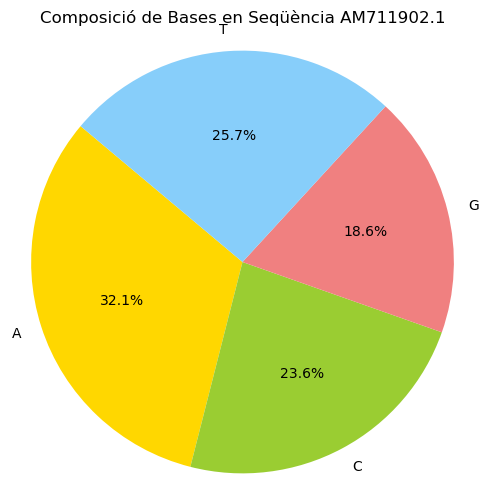

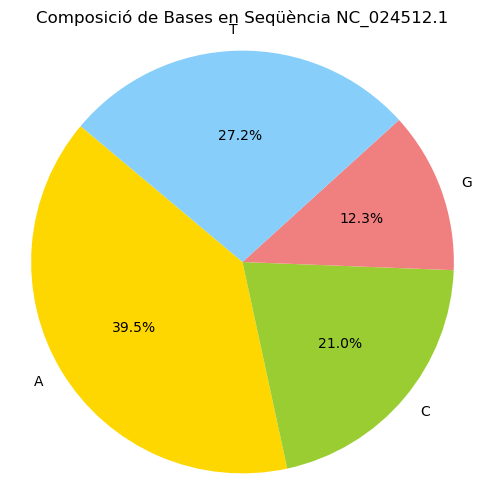

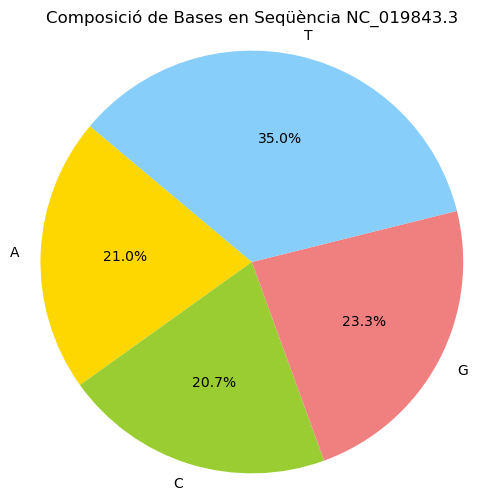

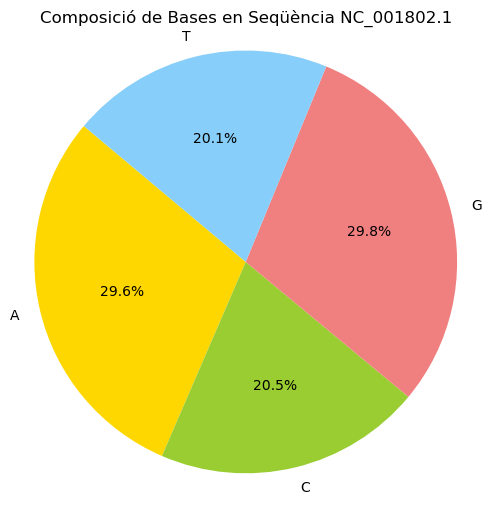

In [161]:
from Bio import SeqIO
import matplotlib.pyplot as plt

import os

def comptar_nucleotids(fasta="multipleSeqs.fa.txt", organisme=''):
    # Completa la teva resposta
    with open(fasta,'r') as f:
        file = f.read().split('>')[1:]
        records = [x.split('\n')[:-1] for x in file]
        #print(records)
    nucleotidos = {}
    for seq_record in records:
        if organisme.lower() in seq_record[0].lower():
            id = seq_record[0].split(' ')[0]
            sequence = ''.join(seq_record[1:])
            nucleotidos[id] = {"A": sequence.count("A"),
                            "C": sequence.count("C"),
                            "G": sequence.count("G"),
                            "T": sequence.count("T")}
    return nucleotidos

def pie_chart_bases(fasta_file):
    # Completa amb la teva resposta
    for i, nucl in comptar_nucleotids(organisme = '').items():
        base_counts = [nucl['A'], nucl['C'], nucl['G'], nucl['T']]
        base_labels = ['A', 'C', 'G', 'T']
        colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']

        plt.figure(figsize=(6, 6))
        plt.pie(base_counts, labels=base_labels, colors=colors, autopct='%1.1f%%', startangle=140)
        plt.title(f"Composició de Bases en Seqüència {i}")
        plt.axis('equal')
        plt.show()


fasta_file = "multipleSeqs.fa.txt"
pie_chart_bases(fasta_file)

### Estructura secundària de l'ADN
La molècula d'ADN té una forma de doble hèlix. L'ordre en seqüència dels nucleòtids determina el que coneixem com a estructura primària de l'ADN. La doble hèlix es forma gràcies a la complementarietat de les bases A i T, i C i G, respectivament. Parlem d'estructura secundària quan ens referim al fet que les bases A i T són complementàries i que C i G també. Per estructura terciària entenem com s'uneixen aquestes bases a l'estructura principal que les suporta i forma una doble hèlix en forma d'espiral.

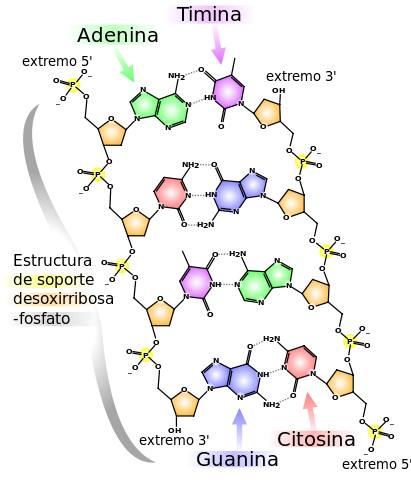

Font: ["DNA chemical structure" - Wikimedia Commons](https://commons.wikimedia.org/wiki/File:DNA_chemical_structure_es.svg#/media/File:DNA_chemical_structure_es.svg)

És interessant conèixer, atesa una seqüència amb bases A, C, G o T, quina és la seva seqüència complementària.

### Exercici d'entrenament 2

La **replicació** de l'ADN és el procés pel qual es copia la informació genètica continguda en una molècula d'ADN a una altra molècula d'ADN. La **transcripció** és el procés pel qual l'ADN es transcriu a ARN. La informació genètica emmagatzemada en l'ADN es transcriu en ARN missatger (ARNm) per mitjà de l'activitat d'un enzim anomenat ARN polimerasa. Podríem dir que la transcripció es tracta d'un pas “intermedi”. Finalment, la **traducció** és el poceso pel qual l'ARN es tradueix en proteïnes. El ARNm es transporta fora del nucli cap al citoplasma on s'uneix als ribosomes. Els ribosomes són els responsables de la síntesi de proteïnes, i utilitzen la informació del ARNm per a produir la seqüència correcta d'aminoàcids que constituiran la proteïna.

Donada una cadena d'ADN, troba la seva cadena complementària. Creiem una funció que ens retorni la seqüència complementària a una cadena d'ADN donada. S'especificaria si volem fer una replicació (ADN -> ADN) o una transcripció (d'ADN-> ARN).

**Replicació:**
* A (Adenina) es complementa amb T (Timina) i C (Citosina) amb G (Guanina).

**Transcripció:**
* A se complementa amb O (Uracil) i C amb G.


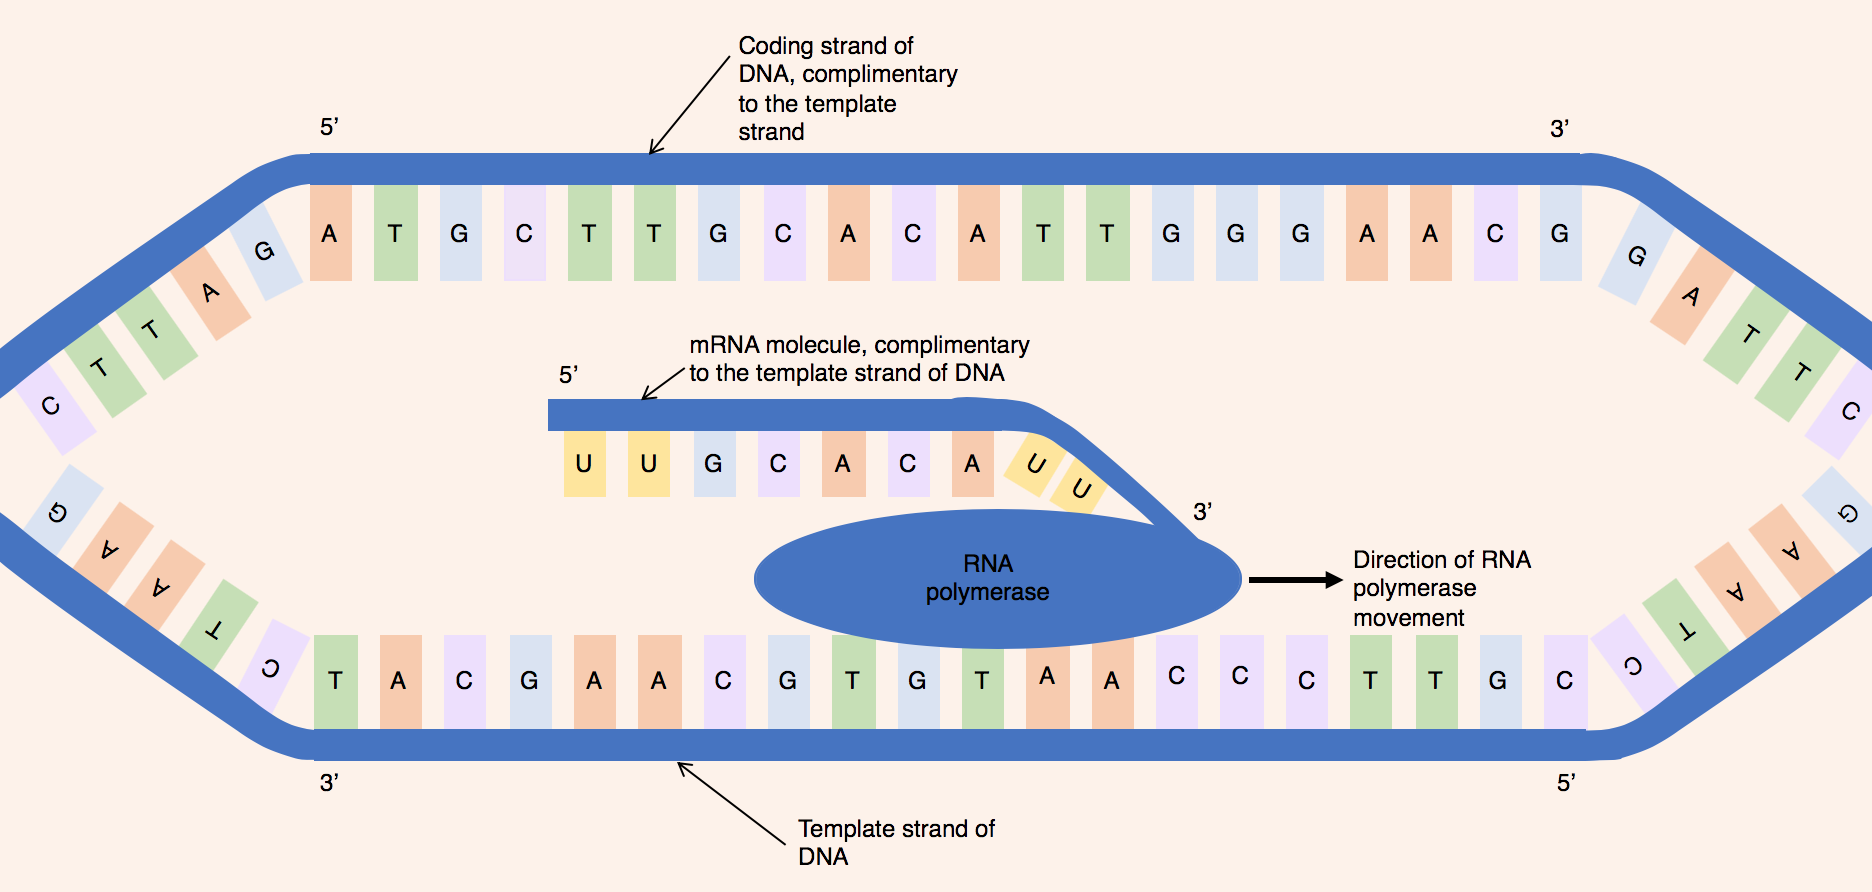

Fuente:  https://upload.wikimedia.org/

**Com seria una funció per a crear la cadena complementària d'una cadena d'ADN?**

In [162]:
# Tingueu en compte que quan es faci la transcripció hem de passar per crear la cadena complementària i d'aquí transcrivim a ARN
def cadena_complementària(cadena_adn, conversion="*replicacion"):
    """
    Donada una cadena d'ADN, troba la seva cadena complementària sense utilitzar BioPython.
    
    Paràmetres:
    - cadena_adn (str): La cadena d'ADN.
    - conversion (str): El tipus de conversió ("replicacion" o "transcripcion").
    
    Retorna:
    - str: La cadena complementària resultant.
    """
    complement_dict = {
        'A': 'T',
        'T': 'A',
        'C': 'G',
        'G': 'C'
    }
    
    # Generar la cadena complementària
    cadena_complementaria = ''.join(complement_dict[base] for base in cadena_adn)
    
    # Si la conversió és per transcripció, substituir T per U
    if conversion == "*transcripcion":
        cadena_complementaria = cadena_complementaria.replace('T', 'U')
    
    return cadena_complementaria
#RESPOSTA

# Exemples d'ús:
ADN_1 = "ATCG" # 5' -> 3'

complement_replicacion = cadena_complementària(ADN_1, conversion="*replicacion")
complement_transcripcion = cadena_complementària(ADN_1, conversion="*transcripcion")

print("Replicació:", complement_replicacion, " # 5' -> 3'")

print("Transcripció:", complement_transcripcion, "# 5' -> 3'")

Replicació: TAGC  # 5' -> 3'
Transcripció: UAGC # 5' -> 3'


### Exercici 4 **<font color="blue" size="+2">EG</font>**
En aquest exercici, escriviu un codi amb Python que calculi, donada una seqüencia, la seva reversa complementària **aquest cop utilitzant la llibreria BioPython**:

In [163]:
sequencia = "CTACTCACCGGATGAAGTGAGGGTCTCACCCCAACGCGGCCTTAGCTTCCTCGGAAGGACCGAACACCTT"

In [164]:
# Resposta
def complementaria(sequencia):
    seq_adn = Seq(sequencia)
        
    # Calcular la reversa complementària
    seq_reversa_complementaria = seq_adn.reverse_complement()
    return seq_reversa_complementaria

Testeja que el teu codi és correcte amb el següent test unitariTestea que tu código es correcto con el siguiente test unitario


In [165]:
%%ipytest
# Test Exercici 4
def test_compl():
  assert complementaria(sequencia) == "AAGGTGTTCGGTCCTTCCGAGGAAGCTAAGGCCGCGTTGGGGTGAGACCCTCACTTCATCCGGTGAGTAG"


.                                                                                            [100%]
1 passed in 0.04s


### Transcripció i traducció
Com ja vam explicar, l'ADN es transcriu a una molècula intermèdia, l'ARN, abans de ser traduït finalment a proteïna. També podem simular aquest aparell biològic mitjançant la llibregia BioPython:

In [166]:
from Bio.Seq import Seq

seq = Seq("ACGACACAGCAAGAAGTCCATACCTTATCATTTAGAGGAAGAAGTCGTAACAAGGTTTCCGTAGGTGAACCCTGA")

# Transcrivim
mRNA = seq.transcribe()

# I traduïm
mRNAt=mRNA.translate()
print (mRNAt)

# El * indica que és un codó que no es tradueix a proteïna. En aquest cas es tracta d'un codó stop.

TTQQEVHTLSFRGRSRNKVSVGEP*


### Acció d'enzims

Els enzims exerceixen un paper fonamental en la biologia en influir en la **estructura i funció** de molècules vitals com el **ADN, ARN i proteïnes**. Aquestes molècules actuen com a instruccions genètiques i maquinària cel·lular, i els enzims faciliten processos clau, com la replicació de l'ADN, la transcripció de l'ADN a ARN i la síntesi de proteïnes. A més, els enzims participen en la modificació i reparació d'aquestes molècules, assegurant la integritat i la funcionalitat del material genètic i les proteïnes essencials per a la vida.


### Exercici d'entrenament 3

La transcriptasa inversa és un enzim que catalitza la síntesi d'ADN a partir d'un motlle d'ARN trobada en alguns virus (e.g. VIH). Crea una funció que simuli l'acció d'una transcriptasa inversa, però solament canviant Timines per Uracil.

In [167]:
# Transformemem les Timines en Uracil
def transcriptasa_inversa(arn_motlle):
    """
    Simula la acció de una transcriptasa inversa que transcriu ARN a ADN.

    Parameters:
    - arn_motlle (str): La seqüencia de ARN que es va a convertir a ADN.

    Returns:
    - str: La seqüencia de ADN resultant.
    """
    #Resposta
    DNA = Seq(arn_motlle).back_transcribe()

    trans_inversa = DNA.replace('T', 'U')
    return trans_inversa


# Cadena de ARN de ejemplo
ARN_4 = "AUGCAUCGUAGCGUAAUGCUAGCAUAGCGUGA"
# Llamada a la función de transcriptasa inversa
cadena_adn_resultant = transcriptasa_inversa(ARN_4)
print(cadena_adn_resultant)

AUGCAUCGUAGCGUAAUGCUAGCAUAGCGUGA


### Exercici d'entrenament 4

Les endonucleases són enzims que tallen l'ADN en llocs específics. Defineix una funció que simuli l'acció d'una endonucleasa dividint una seqüència donada en dues parts. Per a simplificar el procés el lloc de tall sera proporcionat mitjançant un valor numèric.

In [168]:
# Simulació simplificada de la funció de tall del ADN d'una endonucleasa
def endonucleasa_escisio(dna_sequence, lloc_tall):
    """
    Simula la acció d'una endonucleasa que escindeix el ADN en un lloc específic.

    Parameters:
    - dna_sequence (str): La seqüencia de ADN que es va a tallar.
    - lloc_tall (int): La posició en la que la endonucleasa tallará l'ADN.

    Returns:
    - tuple: Les dues hebres d'ADN resultatnt despres del tall.
    """
    #Resposta
    string_1 = dna_sequence[:lloc_tall]
    string_2 = dna_sequence[lloc_tall:]
    return string_1, string_2
# Cadena de ADN exemple
ADN_5 = "ATGATCGTAGCGTAAATGCTAGCATAGCGTGA"
# Crida la función de endonucleasa
hebra1_resultant, hebra2_resultant = endonucleasa_escisio(ADN_5, 10)
print("Cadena origen : ", ADN_5)
print("Lloc de tall: ", 10)
print("Hebra 1: ", hebra1_resultant)
print("Hebra 2: ", hebra2_resultant)


Cadena origen :  ATGATCGTAGCGTAAATGCTAGCATAGCGTGA
Lloc de tall:  10
Hebra 1:  ATGATCGTAG
Hebra 2:  CGTAAATGCTAGCATAGCGTGA


### Exercici 5  **<font color="green" size="+2">MU</font>**
EcoRV és un enzim de restricció molt emprat a tots els laboratoris del món per a tallar una cadena d'ADN en dues parts. EcoRV reconeix el motiu GAT\*ATC, separant la seqüència inicial d'ADN en la posició indicada per '\*'. En la seqüència següent, escriviu un codi amb Python que reconegui aquest motiu (GATATC) i la separi en dues parts (utilitzeu el símbol `+` per indicar les dues parts):

EcoRV(GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGATATCTCCTAATGCTATCCCTCCCCCCTC) = GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGAT + ATCTCCTAATGCTATCCCTCCCCCCTC

In [169]:
seq = 'GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGATATCTCCTAATGCTATCCCTCCCCCCTC'

def ecorv(seq):
    # Resposta
    ecorv_motif = "GATATC"

    motif_index = seq.find(ecorv_motif) #trobem index del motiu

    # Mirem si el motiu pertany a la sequencia
    if motif_index != -1:
        part1 = seq[:motif_index + 3]
        part2 = seq[motif_index+3:]
        
        # Join the parts with '+' and return
        return part1 + " + " + part2
    else:
        return "Motif not found in the sequence"
ecorv(seq)

'GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGAT + ATCTCCTAATGCTATCCCTCCCCCCTC'

Testeja que el teu codi és correcte amb el següent test unitari

In [170]:
%%ipytest
# Test Exercici 5
def test_ecorv():
  assert ecorv(seq) == "GTTGGTGTGCTGCACCTGTTAACTCGTCATTTACATTAAGGAT + ATCTCCTAATGCTATCCCTCCCCCCTC"


.                                                                                            [100%]
1 passed in 0.05s


### Codons
Un codó és un triplet de nucleòtids i cada triplet codifica un aminoàcid (residu), encara que un aminoàcid pot estar codificat per diversos codons. Existeix un codó especial, el codó de parada o terminació que no determina cap aminoàcid, però que indica que la traducció ha d'acabar i la proteïna està completa. Per a la traducció en aminoàcids es necessita d'una **seqüència d'inici o start: ATG** Existeixen tres codons de **parada o stop: TAG, TGA i TAA**. En el nostre exemple, la llibreria ens avisa d'aquest fet.



Podeu consultar una taula de codons aquí: https://en.wikipedia.org/wiki/DNA_codon_table.

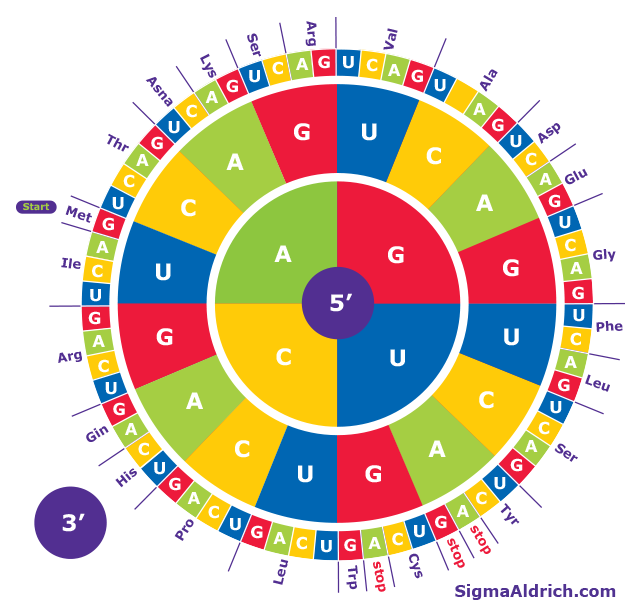

Fuente de la imágen: [www.sigmaaldrich.com](https://www.sigmaaldrich.com/ES/es/technical-documents/technical-article/genomics/sequencing/amino-acid-codon-wheel)

La "forward strand" de l'ADN, també coneguda com a "cadena de bri directe" o "cadena directa" o template strand, es refereix a la cadena de la doble hèlix la seqüència de nucleòtids de la qual es llegeix en la direcció 5' a 3'. Aquest terme és fonamental en el context de la informació genètica continguda en l'ADN. La direcció 5' a 3' significa que la lectura de la seqüència de nucleòtids es realitza d'esquerra a dreta en aquesta cadena específica. Podeu ampliar la informació en els següents links:

- [Cadena de sentit](https://es.wikipedia.org/wiki/cadena_de_sentido)
- [Transcripció genètica](https://es.wikipedia.org/wiki/Transcripci%C3%B3n_gen%C3%*A9tica)
 Neteja


Aquest concepte és essencial per a entendre els processos biològics associats amb l'expressió gènica. Durant la transcripció, en la qual l'ARN missatger (ARNm) es genera a partir de l'ADN, la informació es transcriu des de la "forward strand" cap al ARNm. Posteriorment, en la traducció, la informació continguda en el ARNm guia la síntesi de proteïnes. En aquest context, la "forward strand" serveix com la cadena principal que dicta la seqüència d'aminoàcids en la proteïna resultant. En la següent imatge es representa el codó d'inici i un dels possibles codons de parada o stop:

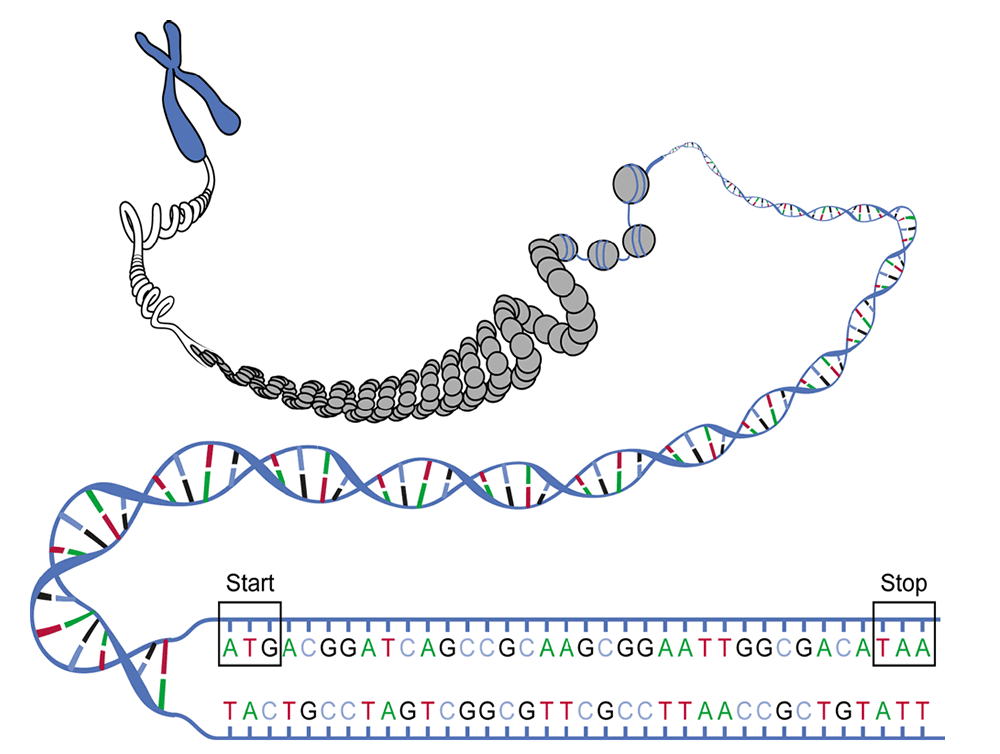

Fuente de la imágen: https://es.wikipedia.org/wiki/Cod%C3%B3n_de_inicio#/media/Archivo:DNA_ORF.png

### Exercici 6 **<font color="blue" size="+2">EG</font>**
En aquest exercici, heu de crear una funció que es detectin els codons stop d'una seqüència de DNA forward i les seves posicions (en llenguatge python, és a dir, començant per 0). Per a aquest cas cal extreure els codons stop (keys) i les seves posicions (values) en un diccionari. La seqüència és la següent: "ATGCGAATAGCTAGCATTGATAAAGCTAAGATTGATA"

**Pista:**

Dins de Bio.SeqUtils hi ha una funció que detecta seqüències de DNA i les seves posicions.

In [171]:
from Bio.SeqUtils import nt_search

codons_stop = ["TAA", "TAG", "TGA"]

def trobar_codons_stop(sequencia_adn_codificante):
     # Completa amb la teva resposta

    # Inicialitzar un diccionari buit per emmagatzemar les posicions dels codons stop
    posicions_codons_stop = {}

    # Iterar sobre la seqüència d'ADN
    for i in range(len(sequencia_adn_codificante) - 2):  # Utilitzem len - 2 per assegurar que no sortirem dels límits de la seqüència
        codon = sequencia_adn_codificante[i:i+3]  # Extreure el codon de tres lletres
        if codon in codons_stop:  # Comprovar si el codon és un codon stop
            if codon not in posicions_codons_stop:  # Comprovar si ja hem registrat aquest codon stop
                posicions_codons_stop[codon] = []  # Inicialitzar una nova entrada de codon stop en el diccionari si no existeix
            posicions_codons_stop[codon].append(i)  # Afegir la posició del codon stop al diccionari

    return posicions_codons_stop

# Seqüència per a extreure codons stop i les seves posicions
sequencia_adn_codificant = "ATGCGAATAGCTAGCATTGATAAAGCTAAGATTGATA"

codons_stop = trobar_codons_stop(sequencia_adn_codificant)


Testea que tu código es correcto con el siguiente test unitario


In [172]:
%%ipytest
# Test Ejercicio 6
def test_ecorv():
  assert codons_stop['TAA'] == [20, 26]
  assert codons_stop['TAG'] == [7, 11]
  assert codons_stop['TGA'] == [17, 32]

.                                                                                            [100%]
1 passed in 0.04s


### Distància de Hamming
La distància de Hamming és una funció entre dues seqüencies p i q (en el nostre cas, ens limitarem a seqüències de la mateixa longitud), que ens indica el nombre de símbols que són diferents per a cada posició i en p i q. Per exemple, p=CCGTA i q=ACGTC. La seva distància de Hamming serà 2 (la primera i l'última posicions són diferents).

### Exercici 7  **<font color="green" size="+2">MU</font>**
Donades dues seqüencies p i q, calculeu la seva distància de Hamming:

In [173]:
p = 'ATTGCCCATAATGTCCCTCAGTAATTCCACTGCACTCGCCACCTTTTTTTTGCAGCTGCTGTGTGCTGGAGCT\
GACCCCTCGGTAATCTCTTGTCTGCTTTTTAGGAACTCCTATCTCCAGATCTTCTTTTACTTCCCAAGCCACC'
q = 'AATGCCCATAATGTCCCTCACTAATTCCACTGCATTTACTTTGCAGCTGCTGTGTGCTGTAGCTGTGAGGAAC\
GCACCCAACTCATCTCTTGTCTGCTTTTTAGGAACCCTATCTCCAGAACTCTTCTTTTACTTAAGGCCTATCC'

def hamming(p, q):
    # Codi a completar
    # Comprovar que les seqüències tenen la mateixa longitud
    if len(p) != len(q):
        raise ValueError("Les seqüències han de tenir la mateixa longitud")

    # Inicialitzar la distància de Hamming
    distance = 0

    # Comparar cada símbol de les seqüències en la mateixa posició
    for i in range(len(p)):
        if p[i] != q[i]:
            distance += 1

    return distance

Testeja que el teu codi és correcte amb el següent test *unitari*

In [174]:
%%ipytest
# Test Exercici 7
def test_hamming():
  assert hamming(p, q) == 73

.                                                                                            [100%]
1 passed in 0.04s


### Motius
En genòmica, és habitual trobar regions d'ADN idèntiques en seqüències de genomes d'organismes diferents, la qual cosa apunta al fet que es tracta d'una regió conservada amb, molt probablement, una funció molt semblant en ambdós organismes.

En el nostre cas, entendrem per motiu una seqüencia *s* amb una longitud menor que la seqüència
*t*, on volem buscar aquest motiu *len(s) < len(t)*. Per exemple, siguin *t* i *s*:

t = GATATATGCATATACTT<br>
s = ATAT<br>

el motiu *s* apareix en les posicions següents: 2, 4 i 10 (comencem a comptar en 1, no és així amb Python, en què comencem a comptar des de 0).

### Exercici 8  **<font color="green" size="+2">MU</font>**
Escriviu una funció que retorni en una llista les posicions on s'ha trobat el motiu en una determinada seqüència (retornarà la llista [-1] si no ha trobat el motiu):

In [175]:
def cercar_motiu(t, s):
    # Codi a completar
    positions = []  # Inicialitzem una llista per emmagatzemar les posicions del motiu

    for i in range(len(t) - len(s) + 1):
        if t[i:i+len(s)] == s:
            positions.append(i)  # Afegim la posició del motiu

    if not positions:  # Si no s'ha trobat el motiu, afegim -1 a la llista de posicions
        positions = [-1]


    return positions

t = 'AUGCUUCAGAAAGGUCUAUACGUGCUUUA'
s = 'CUUA'
print(cercar_motiu(t, s))

t = 'AUGCUUCAGTAAGGUCUUACGUUUAGTCGATUUATCGAGTUU'
s = 'CUU'
print(cercar_motiu(t, s))

t = 'AUGCUUCAGTAAGGUCUUACGUUUAGTCGATUUATCGAGTUU'
s = 'T'
print(cercar_motiu(t, s))

t = 'AUGCUUCAGAAAGGUCUUACGU'
s = 'GU'
print(cercar_motiu(t, s))

t = 'GCGTAGTAGGTTCAAAGCCTAGTTCCGCCGAAAGACAAAGGAGAAGGGAATGCTCCT\
AGTAGTTTCAGTCTAGCAAACATGTTATAACGCTAACTGTGTGCTGCA'
s = 'AAG'
print(cercar_motiu(t, s))

t = 'GCGTAGTAGGTTCGCCTAGTTCCGCCGAAAGACAAAGGAGAAGGGAATGCTCCT\
AGTAGTTTCAGTATAGCAAACATGTTATAACGCCTAACTGTGTGCTGCA'
s = 'AGTC'
print(cercar_motiu(t, s))

[-1]
[3, 15]
[9, 26, 30, 34, 39]
[13, 20]
[14, 31, 37, 43]
[-1]


Testeja que el teu codi és correcte amb el següent test *unitari*

In [176]:
%%ipytest
# Test Exercici 8
def test_motiu():
  t = 'AUGCUUCAGAAAGGUCUAUACGUGCUUUA'
  s = 'CUUA'
  assert cercar_motiu(t, s) == [-1]

  t = 'AUGCUUCAGTAAGGUCUUACGUUUAGTCGATUUATCGAGTUU'
  s = 'CUU'
  assert cercar_motiu(t, s) == [3, 15]

  t = 'AUGCUUCAGTAAGGUCUUACGUUUAGTCGATUUATCGAGTUU'
  s = 'T'
  assert cercar_motiu(t, s) == [9, 26, 30, 34, 39]

  t = 'AUGCUUCAGAAAGGUCUUACGU'
  s = 'GU'
  assert cercar_motiu(t, s) == [13, 20]

  t = 'GCGTAGTAGGTTCAAAGCCTAGTTCCGCCGAAAGACAAAGGAGAAGGGAATGCTCCT\
  AGTAGTTTCAGTCTAGCAAACATGTTATAACGCTAACTGTGTGCTGCA'
  s = 'AAG'
  assert cercar_motiu(t, s) == [14, 31, 37, 43]

  t = 'GCGTAGTAGGTTCGCCTAGTTCCGCCGAAAGACAAAGGAGAAGGGAATGCTCCT\
  AGTAGTTTCAGTATAGCAAACATGTTATAACGCCTAACTGTGTGCTGCA'
  s = 'AGTC'
  assert cercar_motiu(t, s) == [-1]


.                                                                                            [100%]
1 passed in 0.04s


### Mutacions puntuals
Tal com vam calcular en la distància de Hamming, per a dues seqüències de la mateixa longitud i donada una mateixa posició, definim la transició com la substitució d'una purina per una altra purina
(A->G o viceversa) o d'una pirimidina per una altra pirimidina (C->T o viceversa) i la transversió quan se substitueix una purina per una pirimidina o viceversa:


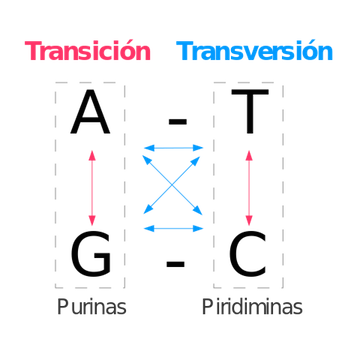


Les transversions ocorren en menor quantitat que les transicions en la naturalesa, atès el canvi dràstic de base química i la relació de transicions enfront de les transversions, que és de 2 de mitjana en el genoma. Però en les regions codificants, aquesta relació és superior (normalment més de 3) i, per tant, és interesant conèixer aquesta relació per a identificar aquestes regions.

Definim R com la relació transicions/transversions. Per a l'exemple següent, hem calculat el valor d'R:

s1 = GCAACGCACAACGAAAACCCTTAGGGACTGGATTATTTCGTGATCGTTGTAGTTATTGGAAGTACGGGCATCAACCCAGTT<br>
s2 = TTATCTGACAAAGAAAGCCGTCAACGGCTGGATAATTTCGCGATCGTGCTGGTTACTGGCGGTACGAGTGTTCCTTTGGGT<br>

R = 1.2142857



### Exercici 9  **<font color="green" size="+2">MU</font>**
Escriviu un codi amb Python que calculi la relació entre les transicions i les transversions:

In [177]:
def rel_trans(s1, s2):
    # Codi a completar
    transitions = 0  # Inicialitzem el comptador de transicions
    transversions = 0  # Inicialitzem el comptador de transversions

    for base1, base2 in zip(s1, s2):  # Iterem a través de les dues seqüències simultàniament
        if base1 != base2:  # Si les bases són diferents
            if (base1 in 'AG' and base2 in 'AG') or (base1 in 'CT' and base2 in 'CT'):  # Si és una transició
                transitions += 1
            else:  # Si és una transversió
                transversions += 1

    return transitions / transversions  # Calculem la relació R

s1 = """TTTTGTCATTTTGCCTCGTCGTCAGGAATATTGGGACGAATTGGACTCTACT
TCTGTGGGCTGAGCCGGTTCACCCATTGACGAGTGCTAGTCACAGATGAATTACAATGAA
CGCTCGAGAAAGTGCTAATAAACGAACAGCACTAACATATGGGGGCGCGGCTGCCGGGCG
ACATGGCCGATTTAAAACACGACTGTAAGGACTGATAAACGTGTAGCATTTTCAAGTCTC
GTCGCGATGTACAAATATCGTGTTCCCTAGCTCAGGGCGCACGCTAAGGACAAACGGTGT
CACCGAATTTTCCAACGGAACACACATCAACGTGCGAGATTTCGTATGTACCCCCAT
TGTATTGAGATGGCATCTGCTCCGAACGTTGAGATCACGCCAGCACTTACAGAACATTCC
TAGTGTGGATCTATTAATAGACGGACTGAAACATTAGGGTGGGAAGTGAGCTATGGCTCA
CACCAAGCATCGGTTTCTTCTTGGACGGTGTCCCCACCATTTGTTATTGTGCTCTAG
AAACACTATAAAGCCTTTAATAAATTCACCGCTGTCGTATCCAAAAGCCGGGTCTGCCTC
CTGATGCGTCTCGCGGCTATGGCTGGGTCACACCCCGACAGTCCAGTACCGTCGGTGCCG
GAGATAGTGTCGCAGGCGTTCTATGGAGATGGACGGCCATCCATACCCAGTCAGCAAAAC
TACCGATCTCTCGGATATCTGTAGGTGGAGCTATTGTCGATAGCTATAAACCAGACTCGG
AGAGTAATATGAAATGGAAGTGAGTGCTGGCGAGGCTTTGTGTACTTGTCTGATTTTGTG
TTGATTTA"""

s2 = """CCTTGTAAGTACGCGTAGCCTCCAGGAACTTTTAGGCGAATTGTACGTCACC
TCCGGGAGCCGGGCCGGTTGATCCTTTGACAAGTCCTCACAGATGTGTCACAACCAACTG
CCCTTGGAAGGGTGCCAGTTAACAAGCGGTAGCAGGACATGAGGACGCGACTGCCGGAAG
ACATGACCAGCTTAAAACACAACTGTCGGGACGGAACGTACTGTATCCTTGAATCTCTTT
GTCGCAGTGTAGAAAAGGCGTTCTCCCTGGTTCAGGGCGCATGCTAGGGATAAACGGTGT
AGTTAAAGATGACGAGGGAAGACGCATCGATGCATGTGACTCCGGATGTACCTCGGT
TATATTGAGAGGGTATCCGCTCGAGACGTTAAAATCCCGTTAGTATTCTCTGGACATTCT
TGACGTGGATCTTTGGCGCGGACTATAGTGGTAGGGCGGGGAGCGACCTATGACTCA
CATCAAGCATCAGCTTTCACTTGGACAGAACTGCGTACACATATCGTTACCGCACTTTGA
AAACATTAGGGAGCTCTTAGTAGATTAGGCGCTGTCGTATCTAAAGGCCAGATCTGTCCT
TTGCTGAATCTCGCGGCCATGTCCGTGTGAAGCCCCGACGACTTAAGGTTAGTGGCGCGA
AAGATAGGGTCGTAGGCGATCGATGGAGATGGATAGCTATGCGTATCCGTTCTGTGGTAT
GCTAAATCTCATAGATAGCTGTGGGTGAAGTTCATATAGACAGCTCTAAGCCACACCCGG
GGAATAATATGGAGTGGGAATGAGAGCTGTCGTGGCTTTGTGCACCTGTCGGATCTCCTA
TTGATCTG"""

print(rel_trans(s1, s2))

1.323943661971831


Testeja que el teu codi és correcte amb el següent test *unitari*

In [178]:
%%ipytest
import pytest
# Test Exercici 9
def test_rel_trans():
    s1 = """TTTTGTCATTTTGCCTCGTCGTCAGGAATATTGGGACGAATTGGACTCTACT
    TCTGTGGGCTGAGCCGGTTCACCCATTGACGAGTGCTAGTCACAGATGAATTACAATGAA
    CGCTCGAGAAAGTGCTAATAAACGAACAGCACTAACATATGGGGGCGCGGCTGCCGGGCG
    ACATGGCCGATTTAAAACACGACTGTAAGGACTGATAAACGTGTAGCATTTTCAAGTCTC
    GTCGCGATGTACAAATATCGTGTTCCCTAGCTCAGGGCGCACGCTAAGGACAAACGGTGT
    CACCGAATTTTCCAACGGAACACACATCAACGTGCGAGATTTCGTATGTACCCCCAT
    TGTATTGAGATGGCATCTGCTCCGAACGTTGAGATCACGCCAGCACTTACAGAACATTCC
    TAGTGTGGATCTATTAATAGACGGACTGAAACATTAGGGTGGGAAGTGAGCTATGGCTCA
    CACCAAGCATCGGTTTCTTCTTGGACGGTGTCCCCACCATTTGTTATTGTGCTCTAG
    AAACACTATAAAGCCTTTAATAAATTCACCGCTGTCGTATCCAAAAGCCGGGTCTGCCTC
    CTGATGCGTCTCGCGGCTATGGCTGGGTCACACCCCGACAGTCCAGTACCGTCGGTGCCG
    GAGATAGTGTCGCAGGCGTTCTATGGAGATGGACGGCCATCCATACCCAGTCAGCAAAAC
    TACCGATCTCTCGGATATCTGTAGGTGGAGCTATTGTCGATAGCTATAAACCAGACTCGG
    AGAGTAATATGAAATGGAAGTGAGTGCTGGCGAGGCTTTGTGTACTTGTCTGATTTTGTG
    TTGATTTA"""

    s2 = """CCTTGTAAGTACGCGTAGCCTCCAGGAACTTTTAGGCGAATTGTACGTCACC
    TCCGGGAGCCGGGCCGGTTGATCCTTTGACAAGTCCTCACAGATGTGTCACAACCAACTG
    CCCTTGGAAGGGTGCCAGTTAACAAGCGGTAGCAGGACATGAGGACGCGACTGCCGGAAG
    ACATGACCAGCTTAAAACACAACTGTCGGGACGGAACGTACTGTATCCTTGAATCTCTTT
    GTCGCAGTGTAGAAAAGGCGTTCTCCCTGGTTCAGGGCGCATGCTAGGGATAAACGGTGT
    AGTTAAAGATGACGAGGGAAGACGCATCGATGCATGTGACTCCGGATGTACCTCGGT
    TATATTGAGAGGGTATCCGCTCGAGACGTTAAAATCCCGTTAGTATTCTCTGGACATTCT
    TGACGTGGATCTTTGGCGCGGACTATAGTGGTAGGGCGGGGAGCGACCTATGACTCA
    CATCAAGCATCAGCTTTCACTTGGACAGAACTGCGTACACATATCGTTACCGCACTTTGA
    AAACATTAGGGAGCTCTTAGTAGATTAGGCGCTGTCGTATCTAAAGGCCAGATCTGTCCT
    TTGCTGAATCTCGCGGCCATGTCCGTGTGAAGCCCCGACGACTTAAGGTTAGTGGCGCGA
    AAGATAGGGTCGTAGGCGATCGATGGAGATGGATAGCTATGCGTATCCGTTCTGTGGTAT
    GCTAAATCTCATAGATAGCTGTGGGTGAAGTTCATATAGACAGCTCTAAGCCACACCCGG
    GGAATAATATGGAGTGGGAATGAGAGCTGTCGTGGCTTTGTGCACCTGTCGGATCTCCTA
    TTGATCTG"""
    assert rel_trans(s1, s2) == pytest.approx(1.3309859154929577)

F                                                                                            [100%]
============================================ FAILURES =============================================
_________________________________________ test_rel_trans __________________________________________

    def test_rel_trans():
        s1 = """TTTTGTCATTTTGCCTCGTCGTCAGGAATATTGGGACGAATTGGACTCTACT
        TCTGTGGGCTGAGCCGGTTCACCCATTGACGAGTGCTAGTCACAGATGAATTACAATGAA
        CGCTCGAGAAAGTGCTAATAAACGAACAGCACTAACATATGGGGGCGCGGCTGCCGGGCG
        ACATGGCCGATTTAAAACACGACTGTAAGGACTGATAAACGTGTAGCATTTTCAAGTCTC
        GTCGCGATGTACAAATATCGTGTTCCCTAGCTCAGGGCGCACGCTAAGGACAAACGGTGT
        CACCGAATTTTCCAACGGAACACACATCAACGTGCGAGATTTCGTATGTACCCCCAT
        TGTATTGAGATGGCATCTGCTCCGAACGTTGAGATCACGCCAGCACTTACAGAACATTCC
        TAGTGTGGATCTATTAATAGACGGACTGAAACATTAGGGTGGGAAGTGAGCTATGGCTCA
        CACCAAGCATCGGTTTCTTCTTGGACGGTGTCCCCACCATTTGTTATTGTGCTCTAG
        AAACACTATAAAGCCTTTAATAAATTCACCGCTGTCGTATCCAAAAGCCG

### Filogènia
BioPython ens permet crear i representar [arbres filogenètics](https://ca.wikipedia.org/wiki/Arbre_filogenètic) de forma àgil i senzilla. En l'exemple següent, utilitzarem un fitxer anomenat simple.dnd que representarà un arbre en [format Newick](https://en.wikipedia.org/wiki/Newick_format) i el representarem:

Tree(rooted=True, weight=1.0)
    Clade()
        Clade()
            Clade()
                Clade(name='A')
                Clade(name='B')
            Clade()
                Clade()
                    Clade(name='C')
                    Clade(name='D')
                        Clade(name='E')
                        Clade(name='F')
        Clade()
            Clade()
                Clade(name='G')
                Clade(name='H')
                    Clade(name='I')
                    Clade(name='J')
        Clade()
            Clade(name='K')


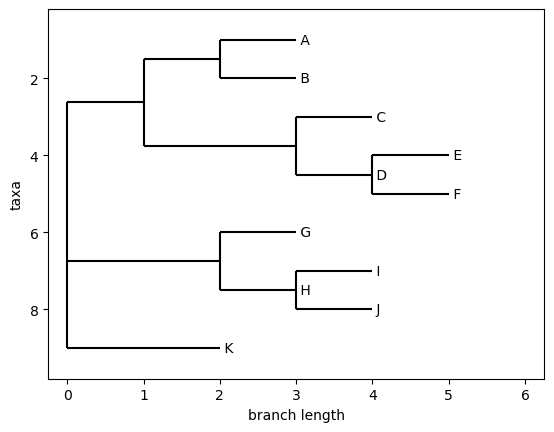

In [179]:
%matplotlib inline

from Bio import Phylo

# Carreguem l'arbre des del fitxer
#!wget -nc https://gitlab.uoclabs.uoc.es/prog_bioinf/data/-/raw/master/Unidad4/simple.dnd --no-check-certificate # Descarreguem el fitxer al nostre drive
tree = Phylo.read("simple.dnd.txt", "newick")

# L'arbre té una arrel
tree.rooted = True

# Imprimim la representació de l'arbre
print(tree)

# Creem una imatge de l'arbre
Phylo.draw(tree)

### Exercici 10  **<font color="blue" size="+2">EG</font>**
Les possibilitats que ofereix la llibreria són molt diverses. Podeu revisar la documentació oficial: http://biopython.org/DIST/docs/tutorial/Tutorial.html#htoc154

Dissenyeu el vostre propi arbre filogenètic en algun format reconeixible per BioPython i representeu-lo d'alguna de les formes possibles. Tingueu en compte que algunes opcions necessitarien llibreries extra com ara networkx o graphviz. **En aquest cas, no les utilitzeu ja que necessitareu instal·lar aquestes llibreries per separat**.

Tree(rooted=True, weight=1.0)
    Clade()
        Clade(name='A')
        Clade()
            Clade(name='B')
            Clade(name='C')
        Clade()
            Clade(name='D')
            Clade(name='E')


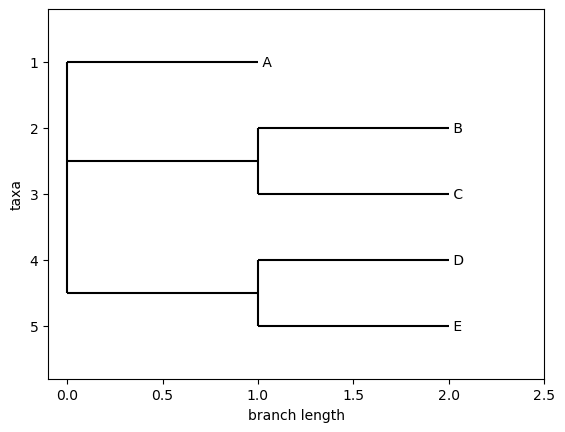

In [180]:
# Resposta
from Bio import Phylo
from io import StringIO

# Crear un árbol filogenético
tree = Phylo.read(StringIO("(A, (B, C), (D, E))"), "newick")

# L'arbre té una arrel
tree.rooted = True

# Imprimim la representació de l'arbre
print(tree)

Phylo.draw(tree)

### Alineament de seqüències
L'alineació de seqüències és una eina essencial en bioinformàtica que permet comparar i analitzar similituds i diferències entre diferents seqüències biològiques. Aquest procés és crucial per a entendre l'estructura i funció de les biomolècules, com l'ADN, i per a realitzar comparacions evolutives entre organismes.

**Referències:**

Mount, D. W. (2004). Bioinformatics: Sequence and Genome Analysis. Cold Spring Harbor Laboratory Press.

Durbin, R., Eddy, S. R., Krogh, A., & Mitchison, G. (1998). Biological Sequence Analysis: Probabilistic Models of Proteins and Nucleic Acids. Cambridge University Press.

Lengauer, T., & Rantala, J. (2002). Bioinformatics: From Genomes to Drugs. Wiley-VCH.

### Exercici 11 **<font color="blue" size="+2">EG</font>**
Tenim dues seqüències d'ADN, i volem realitzar un alineament per a identificar regions d'homologia. En el següent exercici, utilitzem Biopython per a realitzar un alineament de seqüències d'ADN i visualitzar el resultat amb un gràfic en matriu.

*Pista:* les zones on coincideixin (s'alineen) haurien d'estar acolorides d'un color diferent del fons. (e.g.1 = blau, 0 = blanc)

Has d'obtenir una imatge similar a la que es mostra a conitnuacion:

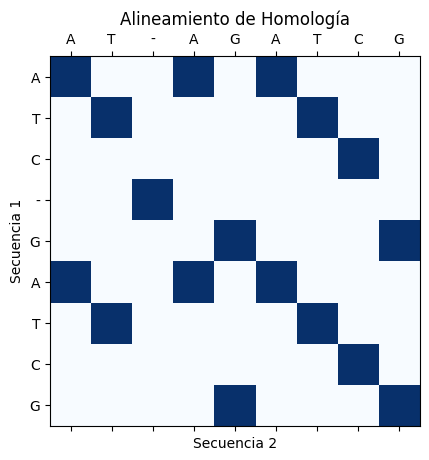

Podeu inspirar-vos en els següents exemples de `matplotlib`
- [Exemple plot matriu 1](https://www.geeksforgeeks.org/matplotlib-axes-axes-matshow-in-python/)
- [Exemple plot matriu 2](https://matplotlib.org/stable/gallery/images_contours_and_fields/matshow.html#sphx-glr-gallery-images-contours-and-fields-matshow-py)

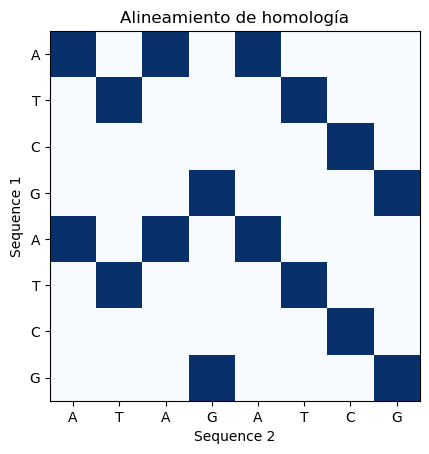

In [181]:
seq1 = "ATCGATCG"
seq2 = "ATAGATCG"

import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(matrix, row_names, col_names):
    plt.imshow(matrix, cmap='Blues', interpolation='nearest')

    # Añadir etiquetas a los ejes
    plt.xticks(ticks=range(len(col_names)), labels=col_names)
    plt.yticks(ticks=range(len(row_names)), labels=row_names)


    # Añadir título y mostrar la matriz
    plt.title('Alineamiento de homología')
    plt.xlabel('Sequence 2')
    plt.ylabel('Sequence 1')
    plt.show()



# Calcular la matriz de confusión
conf_matrix = np.array([[int(a == b) for b in seq2] for a in seq1])

# Nombres de las filas y columnas
nucleotidos_seq1 = list(seq1)
nucleotidos_seq2 = list(seq2)

# Visualizar la matriz de confusión
plot_confusion_matrix(conf_matrix, nucleotidos_seq1, nucleotidos_seq2)

**Autoria**

Autors/es que han participat col·lectivament en aquesta obra:

*   Gabriel Felipe Rodríguez Lozano
*   Pau Andrio Balado
*   Brian Jiménez García
*   Melchor Sanchez Martinez
*   Julia Mir Pedrerol

**Data de creació**


*   Ultima modificació: Desembre 2023